In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
ee=constants.e
a_lattice=2.505
def alpha(a,b,ap,bp):#Herman equation 29
    p = 1
    gamma = a**2 + b ** 2 + a*b #equation 27
    alpha_rad = np.arccos((2*ap*a + 2*bp*b+ap*b+bp*a)/(2*p*gamma))
    alpha_deg = (alpha_rad*180/np.pi)
    lattice=a_lattice*np.sqrt(a**2+b**2+a*b)*np.array([[1,0],[0.5,np.sqrt(3)/2]])
    return alpha_deg,lattice
angle=[]
for i in range(25000):
    angle.append(alpha(i,i+1,i+1,i)[0])
angle=np.array(angle)
angle.shape
ttvec=a_lattice/np.deg2rad(angle)/10
# ttvec.shape
rig_pmax=np.loadtxt('rig_p1_max')
rel_p1_max=np.loadtxt('rel_p1_max')
rel_p3_max=np.loadtxt('rel_p3_max')
rig_vm=np.loadtxt('0_rig_vmax.dat')
np.max(angle)
np.savetxt('angle.dat',angle)

In [2]:
dd =np.linspace(10,200,7)
rigp=rig_pmax
pm1=rel_p1_max
pm3=rel_p3_max
GG1=4*np.pi/(np.sqrt(3)*ttvec*10)
GG3=8*np.pi/(np.sqrt(3)*ttvec*10)
np.max(ttvec)


10846.75097397363

In [3]:
aa=alpha(5,6,6,5)[0]
bb=a_lattice/np.deg2rad(aa)
np.min(ttvec)

0.2392098794671187

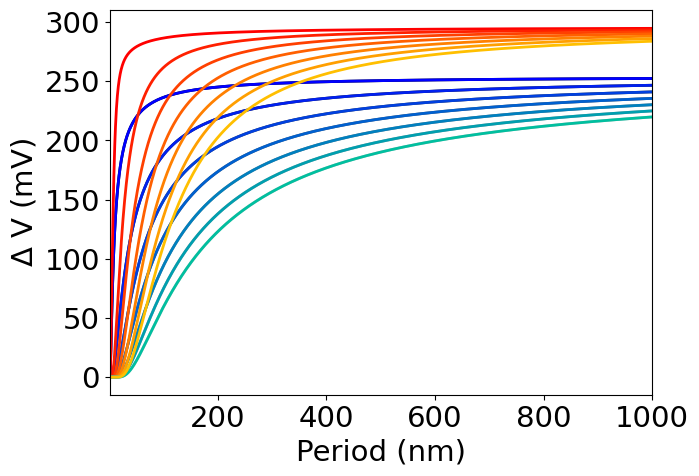

In [5]:

diele=constants.epsilon_0
plt.figure(figsize=(7,5))
sss=21
cmap = plt.get_cmap('winter', 9)#int(ccut.shape[0]))
cmap2 = plt.get_cmap('autumn', 9)#int(ccut.shape[0]))
cmap3=plt.get_cmap('gray', 9)
# rrr=np.arange()
for ii in range(0,dd.shape[0]):
    co=cmap(ii)
    co2=cmap2(ii)
    co3=cmap3(ii)
    epr=1
    vr=np.exp(-GG1*dd[ii])*(2.25*1e-12)/(2*diele)*1000#mV
    c1_p=np.exp(-GG1*dd[ii])*(pm1*1e-12)/(2*diele*epr)*1000
    c3_p=np.exp(-GG3*dd[ii])*(pm3*1e-12)/(2*diele*epr)*1000
    rig=np.exp(-GG1*dd[ii])*(rigp*1e-12)/(2*diele*epr)*1000
    plt.plot(ttvec,vr*2,label=f'{round(dd[ii]/10)} $nm$',color=co3,lw=2)
    # plt.plot(ttvec,vr*2,color=co3,lw=2,ls='dashdot')
    # plt.plot(ttvec,rig_vm[ii,:],label=f'{round(dd[ii]/10)} $nm$',color=co,lw=2) 
    plt.plot(ttvec,rig_vm[ii,:],color=co,lw=2) 
    # plt.plot(ttvec,(c3_p+c1_p)*2,label=f'{round(dd[ii]/10)} $nm$',color=co2,lw=2) 
    plt.plot(ttvec,(c3_p+c1_p)*2,color=co2,lw=2) 
# plt.legend(loc=3, bbox_to_anchor=(0.25,0.03),borderaxespad = 0.,fontsize=sss-11)
# plt.legend(loc=3,fontsize=sss-10)
plt.xlabel('Period (nm)',fontsize=sss)
plt.ylabel('$\Delta$ V (mV)',fontsize=sss)
plt.xticks(fontsize=sss)
plt.yticks(fontsize=sss)
plt.xlim(1,1000)

plt.savefig('0moire_potential.pdf',bbox_inches='tight')
